## CASCADE Conformal Prediction: Uncertainty-Adaptive Prediction Intervals for Two-Stage Clinical Decision Support

Official Implementation of "CASCADE Conformal Prediction: Uncertainty-Adaptive Prediction Intervals for Two-Stage Clinical Decision Support" (Diaz-Rincon et al., 2026).

(Diaz-Rincon et al., 2025) used the predicted probability of LEDD change for prediction of medication needs in Parkinson's Disease patients in a Two-Stage emsamble.

Our current approach calculates the patient's epistemic uncertainty in Stage 1 through Venn Abers (VA) uncertainty to inform Stage 2 Conformal Prediction (CP) intervals.

Findings:
- Low uncertainty → Stage 2 provides narrow intervals (confident)
- High uncertainty → Stage 2 provides wide intervals (cautious)

This is the CASCADE effect: Stage 1 confidence propagates to Stage 2, adapting the prediction intervals.

In [5]:
!pip install venn-abers
!pip install mapie==0.8.6

In [6]:
import pandas as pd
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from venn_abers import VennAbers

from mapie.regression import MapieRegressor
from mapie.metrics import regression_coverage_score, regression_mean_width_score
from mapie.subsample import Subsample

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.utils import resample
from scipy.stats import ttest_1samp, bootstrap

import warnings
warnings.filterwarnings('ignore', message='WARNING: The predictions are ill-sorted')

In [48]:
# Global Configuration
RANDOM_STATE = 21
ALPHA = 0.2 # Targetting 80% Coverage

# Conformal Methods
STRATEGIES = {
    "naive": {"method": "naive"},
    "split": {'method': 'base'},
    "cv_plus": {"method": "plus", "cv": 10},
    "jackknife_plus_ab": {"method": "plus", "cv": Subsample(n_resamplings=50)},
}

# XGBoost Parameters
XGBOOST_BINARY_PARAMS = {
    "eval_metric": "auc",
    "objective": "binary:logistic",
    'sampling_method': 'gradient_based',
    'alpha': 0.1,
    'lambda': 1,
    'learning_rate': 0.1,
    'max_depth': 7,
    'tree_method': 'hist',
    'device': "cuda",
}

XGBOOST_REGRESSION_PARAMS = {
    'alpha': 0.1,
    'lambda': 1,
    'learning_rate': 0.1,
    'max_depth': 7,
    'n_estimators': 700,
    "eval_metric": 'rmse',
    'objective': 'reg:squarederror',
    'sampling_method': 'gradient_based',
    'tree_method': 'hist',
    'device': "cuda"
}

# Colors
color_azure = '#0097B2'
color_orange = '#F35000'
color_red = '#B00000'
color_gold = '#FFD700'

## Data Loading and Preprocessing

In [8]:
path = 'data_1Y.csv'
data = pd.read_csv(path)

# Continous Outcome (LEDD Change)
normalized_pctg_change = data['normalized_percent_change']  # Save for Stage 2
data.drop(columns=['normalized_percent_change'], inplace=True)

# Prepare features
xgboost_df = data.copy()

# One-hot encoding
demographic_vars = ['gender_source_value', 'race_source_value', 'ethnicity_source_value']
xgboost_df = pd.get_dummies(xgboost_df, columns=demographic_vars)

# Scaling
scaler = MinMaxScaler()
numeric_vars = ['mean_led_per_visit', 'age', 'length_of_stay', 'days_since_last_visit', 'days_to_diagnosis']
for var in numeric_vars:
    xgboost_df[var] = scaler.fit_transform(xgboost_df[[var]])

# Reordering columns
prediction_to_last = xgboost_df.pop('prediction')
xgboost_df['prediction'] = prediction_to_last

# Features and targets
X = xgboost_df.iloc[:, :-1]
y_binary = xgboost_df.iloc[:, -1]  # Binary: medication change needed
y_continuous = normalized_pctg_change  # Continuous: percent change in LEDD

# Stage 1: Binary Classification with Venn-Abers
Get VA uncertainty estimates for ALL patients in Stage 1 binary prediction. This will inform Stage 2 interval widths instead of filtering out patients

In [53]:
print("Stage 1: Binary Classification + Venn-Abers Calibration")

# Split for Stage 1: Train on 80%, use 20% for VA calibration
X_train_stage1, X_test_stage1, y_train_stage1, y_test_stage1 = train_test_split(
    X, y_binary, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Stage 1 Split | Training: {len(X_train_stage1)} ({len(X_train_stage1)/len(X)*100:.1f}%) | VA Calibration: {len(X_test_stage1)} ({len(X_test_stage1)/len(X)*100:.1f}%)")

# Train XGBoost binary classifier on FULL training set
d_train = xgb.DMatrix(X_train_stage1, label=y_train_stage1)
d_test = xgb.DMatrix(X_test_stage1, label=y_test_stage1)

print("\nTraining Stage 1 XGBoost classifier...")
model_stage1 = xgb.train(
    XGBOOST_BINARY_PARAMS,
    d_train,
    num_boost_round=700,
    evals=[(d_test, "validation")],
    verbose_eval=100,
    early_stopping_rounds=10
)

# Venn-Abers Calibration
print("\nGetting predictions for Venn-Abers calibration on test set ...")
p_test_uncalibrated = model_stage1.predict(d_test, iteration_range=(0, model_stage1.best_iteration + 1))
# Convert to 2D for VennAbers library
p_test_2d = np.column_stack([1 - p_test_uncalibrated, p_test_uncalibrated])


va = VennAbers()
va.fit(p_test_2d, y_test_stage1.values)

# Getting Global Uncertainty (VA predictions for ALL patients)
print("\nComputing VA uncertainty scores for the full patient cohort")
d_all = xgb.DMatrix(X)
p_all_uncalibrated = model_stage1.predict(d_all,iteration_range=(0, model_stage1.best_iteration + 1))
# Convert to 2D and get VA intervals
p_all_2d = np.column_stack([1 - p_all_uncalibrated, p_all_uncalibrated])

p_lower_all_2d, p_upper_all_2d = va.predict_proba(p_all_2d)

# Extract predictions for class 1 (needs medication change)
p_lower_all = p_lower_all_2d[:, 1]
p_upper_all = p_upper_all_2d[:, 1]
va_uncertainty_all = p_upper_all - p_lower_all

print(f"VA Uncertainty Stats (n={len(X)}): Mean={va_uncertainty_all.mean():.4f}, Median={np.median(va_uncertainty_all):.4f}, Max={va_uncertainty_all.max():.4f}")

Stage 1: Binary Classification + Venn-Abers Calibration
Stage 1 Split | Training: 4884 (80.0%) | VA Calibration: 1221 (20.0%)

Training Stage 1 XGBoost classifier...
[0]	validation-auc:0.86331
[100]	validation-auc:0.95127
[200]	validation-auc:0.96279
[269]	validation-auc:0.96532

Getting predictions for Venn-Abers calibration on test set

Computing VA uncertainty scores for the full patient cohort
VA Uncertainty Stats (n=6105): Mean=0.0062, Median=0.0003, Max=0.2381


# Selection of Stage 2 patients

We do not filter by probability threshold but use only patients who actually need medication change (y_binary == 1)

In [55]:
print("Stage 2 Subpopulation Selection")
print("Selection criterion: y_binary == 1 (True Positives: Actually needs medication change)")
# Use only patients who actually need medication change. No probability filtering
mask = (y_binary == 1)
X_stage2 = X[mask]
y_stage2 = y_continuous[mask] #Previously saved variable that contains the normalized LEDD change
va_uncertainty_stage2 = va_uncertainty_all[mask]

# Get VA uncertainty for the selected patients.
p_lower_stage2 = p_lower_all[mask]
p_upper_stage2 = p_upper_all[mask]

print(f"Patients selected: {len(X_stage2)} / {len(X)} ({len(X_stage2)/len(X)*100:.1f}%)")
print(f"  Mean: {va_uncertainty_stage2.mean():.4f} | Std: {va_uncertainty_stage2.std():.4f} | Range: [{va_uncertainty_stage2.min():.4f}, {va_uncertainty_stage2.max():.4f}]")

Stage 2 Subpopulation Selection
Selection criterion: y_binary == 1 (True Positives: Actually needs medication change)
Patients selected: 1533 / 6105 (25.1%)
  Mean: 0.0202 | Std: 0.0338 | Range: [0.0002, 0.2381]


Stage 2 Split

In [11]:
print("Stage 2: Train/Test Split")

X_train_2, X_test_2, y_train_2, y_test_2, \
va_unc_train_2, va_unc_test_2, \
p_lower_train_2, p_lower_test_2 = train_test_split(
    X_stage2, y_stage2,
    va_uncertainty_stage2,
    p_lower_stage2,
    test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training: {len(X_train_2)} patients")
print(f"Test:     {len(X_test_2)} patients")
print(f"Mean LEDD change (train): {y_train_2.mean():.3f}")
print(f"Mean LEDD change (test):  {y_test_2.mean():.3f}")

# Train base regression model

print("\nTraining base regression model...")
xgb_model_base = xgb.XGBRegressor(**XGBOOST_REGRESSION_PARAMS, random_state=RANDOM_STATE)
xgb_model_base.fit(X_train_2, y_train_2)

y_pred_base = xgb_model_base.predict(X_test_2)
rmse = np.sqrt(mean_squared_error(y_test_2, y_pred_base))
mae = mean_absolute_error(y_test_2, y_pred_base)
r2 = r2_score(y_test_2, y_pred_base)

print(f"Base Model Performance:")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")
print(f"  R²:   {r2:.4f}")

Stage 2: Train/Test Split
Training: 1226 patients
Test:     307 patients
Mean LEDD change (train): 0.017
Mean LEDD change (test):  0.036

Training base regression model...
Base Model Performance:
  RMSE: 0.0995
  MAE:  0.0380
  R²:   0.9801


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [19:07:58] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


# Conformal Methods

# Experiment 1: Baseline (No VA Uncertainty)

In [13]:
print("Experiment 1: Baseline (No VA Uncertainty)")
print("Standard conformal prediction - uniform intervals for all patients")
results_baseline = {}

for strategy, params in STRATEGIES.items():
    # Standard MAPIE conformal prediction
    mapie = MapieRegressor(
        xgb_model_base,
        test_size=0.2,
        **params,
        random_state=RANDOM_STATE
    )
    mapie.fit(X_train_2, y_train_2)
    y_pred, y_pis = mapie.predict(X_test_2, alpha=ALPHA)

    # Evaluate
    coverage = regression_coverage_score(y_test_2, y_pis[:, 0, 0], y_pis[:, 1, 0])
    width = regression_mean_width_score(y_pis[:, 0, 0], y_pis[:, 1, 0])

    results_baseline[strategy] = {
        'y_pred': y_pred,
        'y_pis': y_pis,
        'coverage': coverage,
        'width': width,
        'method': 'baseline'
    }

    print(f"  {strategy:20s}: Coverage={coverage:.3f}, Width={width:.3f}")

Experiment 1: Baseline (No VA Uncertainty)
Standard conformal prediction - uniform intervals for all patients
  naive               : Coverage=0.524, Width=0.031
  split               : Coverage=0.840, Width=0.113
  cv_plus             : Coverage=0.834, Width=0.100
  jackknife_plus_ab   : Coverage=0.648, Width=0.139


# Experiment 2: Stratified by VA Uncertainty (Mondrian CP)

Here we separate CP per uncertainty level e.g low, med, high based on uncertainty quantiles from the VA estimates

In [14]:
print("Stratified VA (Mondrian CP)")
# Create uncertainty bins using training set quantiles
# This ensures train and test use SAME bin boundaries
quantiles = [0, 0.20, 0.4, 0.60, 0.80, 1.0]
bin_edges = np.percentile(va_unc_train_2, [0, 14.285, 28.571, 42.857, 57.142, 71.428, 85.7142, 100])

print(f"\nBin Definitions (from training set):")
print(f"  LOW:    [{bin_edges[0]:.4f}, {bin_edges[1]:.4f})")
print(f"  MEDIUM: [{bin_edges[1]:.4f}, {bin_edges[2]:.4f})")
print(f"  HIGH:   [{bin_edges[2]:.4f}, {bin_edges[3]:.4f}]")

# Apply same bins to both train and test
bins_train = pd.cut(va_unc_train_2, bins=bin_edges, labels=['1', '2', '3', '4', '5', '6', '7'],
                   include_lowest=True, duplicates='drop')
bins_test = pd.cut(va_unc_test_2, bins=bin_edges, labels=['1', '2', '3', '4', '5', '6', '7'],
                  include_lowest=True, duplicates='drop')

print(f"\nBin Distribution:")
print("  Training:")
for cat in ['low', 'medium', 'high']:
    n = (bins_train == cat).sum()
    unc = va_unc_train_2[bins_train == cat]
    if len(unc) > 0:
        print(f"    {cat:8s}: {n:4d} samples, uncertainty [{unc.min():.4f}, {unc.max():.4f}]")
print("  Test:")
for cat in ['low', 'medium', 'high']:
    n = (bins_test == cat).sum()
    unc = va_unc_test_2[bins_test == cat]
    if len(unc) > 0:
        print(f"    {cat:8s}: {n:4d} samples, uncertainty [{unc.min():.4f}, {unc.max():.4f}]")

results_stratified = {}

for strategy, params in STRATEGIES.items():
    print(f"\n  Running Stratified {strategy}...")

    # Initialize arrays for full test set
    y_pred_all = np.zeros(len(X_test_2))
    y_lower_all = np.zeros(len(X_test_2))
    y_upper_all = np.zeros(len(X_test_2))

    results_by_bin = {}

    # Process each uncertainty bin separately
    for category in ['1', '2', '3', '4', '5', '6', '7']:
        mask_train = (bins_train == category)
        mask_test = (bins_test == category)

        n_train_cat = mask_train.sum()
        n_test_cat = mask_test.sum()

        # Check if we have enough data
        if n_train_cat < 10 or n_test_cat < 2:
            print(f"    {category:8s}: SKIPPED (insufficient data)")
            continue

        print(f"    {category:8s}: Training on {n_train_cat} samples...")

        # Get data for this bin
        X_train_cat = X_train_2[mask_train]
        y_train_cat = y_train_2[mask_train]
        X_test_cat = X_test_2[mask_test]
        y_test_cat = y_test_2[mask_test]

        # Train model for this bin
        model_cat = xgb.XGBRegressor(**XGBOOST_REGRESSION_PARAMS, random_state=RANDOM_STATE)
        model_cat.fit(X_train_cat, y_train_cat)

        # Conformal prediction for this bin
        mapie_cat = MapieRegressor(
            model_cat,
            test_size=0.2,
            **params,
            random_state=RANDOM_STATE
        )
        mapie_cat.fit(X_train_cat, y_train_cat)
        y_pred_cat, y_pis_cat = mapie_cat.predict(X_test_cat, alpha=ALPHA)

        # Store results for this bin
        y_pred_all[mask_test] = y_pred_cat
        y_lower_all[mask_test] = y_pis_cat[:, 0, 0]
        y_upper_all[mask_test] = y_pis_cat[:, 1, 0]

        # Per-bin metrics
        cov_cat = regression_coverage_score(
            y_test_cat, y_pis_cat[:, 0, 0], y_pis_cat[:, 1, 0]
        )
        width_cat = regression_mean_width_score(
            y_pis_cat[:, 0, 0], y_pis_cat[:, 1, 0]
        )

        results_by_bin[category] = {
            'coverage': cov_cat,
            'width': width_cat,
            'n_test': n_test_cat,
            'n_train': n_train_cat
        }

        print(f"              Coverage={cov_cat:.3f}, Width={width_cat:.3f}")

    # Overall metrics
    coverage = np.mean((y_test_2 >= y_lower_all) & (y_test_2 <= y_upper_all))
    width = np.mean(y_upper_all - y_lower_all)
    CR = results_by_bin['7']['width'] / results_by_bin['1']['width']

    results_stratified[strategy] = {
        'y_pred': y_pred_all,
        'y_lower': y_lower_all,
        'y_upper': y_upper_all,
        'coverage': coverage,
        'width': width,
        'results_by_bin': results_by_bin,
        'method': 'stratified'
    }

    print(f"    OVERALL:   Coverage={coverage:.3f}, Width={width:.3f}")
    print(f"    CR:   {CR:.2f}")

Stratified VA (Mondrian CP)

Bin Definitions (from training set):
  LOW:    [0.0002, 0.0053)
  MEDIUM: [0.0053, 0.0066)
  HIGH:   [0.0066, 0.0076]

Bin Distribution:
  Training:
  Test:

  Running Stratified naive...
    1       : Training on 180 samples...
              Coverage=0.608, Width=0.024
    2       : Training on 174 samples...
              Coverage=0.667, Width=0.042
    3       : Training on 244 samples...
              Coverage=0.717, Width=0.030
    4       : Training on 102 samples...
              Coverage=0.731, Width=0.029
    5       : Training on 175 samples...
              Coverage=0.605, Width=0.019
    6       : Training on 176 samples...
              Coverage=0.556, Width=0.027
    7       : Training on 175 samples...
              Coverage=0.595, Width=0.031
    OVERALL:   Coverage=0.635, Width=0.029
    CR:   1.27

  Running Stratified split...
    1       : Training on 180 samples...
              Coverage=0.784, Width=0.094
    2       : Training on 174 

Comprehensive Comparison

In [15]:
print("How Stage 1 VA Uncertainty Propagates to Stage 2 Intervals:")
for conf_method in ["naive", "split", "cv_plus", "jackknife_plus_ab"]:
    if 'results_by_bin' not in results_stratified[conf_method]:
        continue

    print(f"\n{conf_method.upper()}:")

    for bin_name in ['low', 'medium', 'high']:
        if bin_name not in results_stratified[conf_method]['results_by_bin']:
            continue

        bin_res = results_stratified[conf_method]['results_by_bin'][bin_name]
        mask = (bins_test == bin_name)
        unc_range = va_unc_test_2[mask]

        print(f"  {bin_name.upper():8s} Stage 1 Uncertainty [{unc_range.min():.4f}, {unc_range.max():.4f}]")
        print(f"    → Stage 2 Width:    {bin_res['width']:.4f}")
        print(f"    → Coverage:         {bin_res['coverage']:.4f}")
        print(f"    → N samples:       {bin_res['n_test']}")

How Stage 1 VA Uncertainty Propagates to Stage 2 Intervals:

NAIVE:

SPLIT:

CV_PLUS:

JACKKNIFE_PLUS_AB:


# Statistical Comparison
We compare both Baseline (Standard CP) and Two-Stage with the Stratified and Weighted approaches.
For each: Mean, 95% Bootstrap CI, Absolute/Relative Change, t-test, Cohen's d

In [16]:
# Baseline and Two-Stage from Table 7 (1Y)
methods = ['naive', 'split', 'cv_plus', 'jackknife_plus_ab']
method_names = {'naive': 'Naive', 'split': 'split', 'cv_plus': 'CV+', 'jackknife_plus_ab': 'J+aB'}

stratified = {
    'naive': {'coverage': results_stratified['naive']['coverage'], 'width': results_stratified['naive']['width']},
    'split': {'coverage': results_stratified['split']['coverage'], 'width': results_stratified['split']['width']},
    'cv_plus': {'coverage': results_stratified['cv_plus']['coverage'], 'width': results_stratified['cv_plus']['width']},
    'jackknife_plus_ab': {'coverage': results_stratified['jackknife_plus_ab']['coverage'], 'width': results_stratified['jackknife_plus_ab']['width']}
}

baseline = {
    'naive': {'coverage': results_baseline['naive']['coverage'], 'width': results_baseline['naive']['width']},
    'split': {'coverage': results_baseline['split']['coverage'], 'width': results_baseline['split']['width']},
    'cv_plus': {'coverage': results_baseline['cv_plus']['coverage'], 'width': results_baseline['cv_plus']['width']},
    'jackknife_plus_ab': {'coverage': results_baseline['jackknife_plus_ab']['coverage'], 'width': results_baseline['jackknife_plus_ab']['width']}
}

In [17]:
results_stratified['naive']['results_by_bin']

{'1': {'coverage': 0.6081081081081081,
  'width': 0.024277582168578993,
  'n_test': np.int64(74),
  'n_train': np.int64(180)},
 '2': {'coverage': 0.6666666666666666,
  'width': 0.04218308210372923,
  'n_test': np.int64(45),
  'n_train': np.int64(174)},
 '3': {'coverage': 0.717391304347826,
  'width': 0.029680144786834676,
  'n_test': np.int64(46),
  'n_train': np.int64(244)},
 '4': {'coverage': 0.7307692307692307,
  'width': 0.028910288810729986,
  'n_test': np.int64(26),
  'n_train': np.int64(102)},
 '5': {'coverage': 0.6052631578947368,
  'width': 0.018820004463195872,
  'n_test': np.int64(38),
  'n_train': np.int64(175)},
 '6': {'coverage': 0.5555555555555556,
  'width': 0.027064990997314412,
  'n_test': np.int64(36),
  'n_train': np.int64(176)},
 '7': {'coverage': 0.5952380952380952,
  'width': 0.030917315483093295,
  'n_test': np.int64(42),
  'n_train': np.int64(175)}}

Cascade Ratio by Conformal Method

In [18]:
# ratio_data = []
# for method in methods:
#     low_width = np.mean(stratified[method]['width'][bins_test == 'low'])
#     high_width = np.mean(stratified[method]['width'][bins_test == 'high'])
#     ratio = high_width / low_width

#     ratio_data.append({
#         'Method': method_names[method],
#         'LOW Width': f'{low_width:.3f}',
#         'HIGH Width': f'{high_width:.3f}',
#         'Ratio (HIGH/LOW)': f'{ratio:.2f}×'
#     })

# df_cascade_ratios = pd.DataFrame(ratio_data)
# display(df_cascade_ratios)

Visualizations

In [19]:
from sklearn.model_selection import train_test_split

# 1. Split Training Data into "Proper Train" and "Calibration" sets
# We need a fresh set of data to calibrate the scores, otherwise residuals are too small.
X_train_proper, X_calib, y_train_proper, y_calib, va_unc_proper, va_unc_calib = train_test_split(
    X_train_2, y_train_2, va_unc_train_2,
    test_size=0.2,  # Use 40% for calibration to get a robust quantile
    random_state=42
)

print(f"Split Statistics:")
print(f"  Proper Training: {len(X_train_proper)} samples")
print(f"  Calibration:     {len(X_calib)} samples")
print(f"  Test:            {len(X_test_2)} samples")

# 2. Retrain Base Model on Proper Training Set ONLY
print("\nRetraining base model on Proper Training set...")
xgb_model_proper = xgb.XGBRegressor(**XGBOOST_REGRESSION_PARAMS)
xgb_model_proper.fit(X_train_proper, y_train_proper)

Split Statistics:
  Proper Training: 980 samples
  Calibration:     246 samples
  Test:            307 samples

Retraining base model on Proper Training set...


XGBRegressor(alpha=0.1, base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cuda', early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None, lambda=1,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=700, ...)

In [20]:
print("MEAN-CENTERED CASCADE CP")
va_unc_test_array = np.asarray(va_unc_test_2)

def get_scaling_factor_centered(va_uncertainty, global_mean_unc, beta=0.5, min_scale=0.2, max_scale=5.0):
    # Normalize uncertainty: (u / u_bar) - 1
    # This creates a value centered at 0.
    # range is roughly [-1.0, +infinity]
    norm_diff = (va_uncertainty / global_mean_unc) - 1.0

    # Apply Beta magnitude
    # Sigma will be 1.0 + adjustment
    sigma = 1.0 + (beta * norm_diff)

    # Clip to ensure positive sigma
    # min_scale=0.2 means the interval can never shrink below 20% of the standard width
    # This prevents the "Over-confidence Trap" that ruined Method 6
    sigma = np.clip(sigma, a_min=min_scale, a_max=max_scale)
    return sigma

# Experiment with different Beta strengths
# Beta=0.5: Moderate adjustments
# Beta=1.0: Aggressive (Confident patients get ~0 width, Uncertain get ~2x width)
betas_centered = [0.3, 0.5, 0.7, 1.0]

print(f"{'Beta':<6} | {'Coverage':<10} | {'Avg Width':<10} | {'Cascade Ratio':<15}")
print("-" * 50)

# Need global mean from proper training set
global_mean_unc = np.mean(va_unc_proper)

for b in betas_centered:
    # A. Calibrate
    sigma_calib = get_scaling_factor_centered(va_unc_calib, global_mean_unc, beta=b)
    residuals_calib = np.abs(y_calib - xgb_model_proper.predict(X_calib))
    scores = residuals_calib / sigma_calib

    # Quantile
    n_calib = len(scores)
    q_level = np.ceil((n_calib + 1) * (1 - ALPHA)) / n_calib
    q_hat = np.quantile(scores, min(1.0, q_level), method='higher')

    # B. Test
    sigma_test = get_scaling_factor_centered(np.array(va_unc_test_array), global_mean_unc, beta=b)
    y_pred_test = xgb_model_proper.predict(X_test_2)

    half_width = q_hat * sigma_test
    y_lower = y_pred_test - half_width
    y_upper = y_pred_test + half_width

    # C. Metrics
    cov = regression_coverage_score(y_test_2, y_lower, y_upper)
    width = regression_mean_width_score(y_lower, y_upper)

    # Cascade Ratio
    # high_mask = va_unc_test_array > np.median(va_unc_test_array)
    # width_high = np.mean((y_upper - y_lower)[high_mask])
    # width_low = np.mean((y_upper - y_lower)[~high_mask])
    # ratio = width_high / width_low if width_low > 0 else 0
    # --- UPDATED CASCADE RATIO (Tertiles to match Paper) ---
    # 1. Define thresholds based on the test set distribution
    tertile_low = np.percentile(va_unc_test_array, 14.28)
    tertile_high = np.percentile(va_unc_test_array, 28.57)

    # 2. Create Masks for Top/Bottom Tertiles
    mask_low_unc = va_unc_test_array <= tertile_low
    mask_high_unc = va_unc_test_array >= tertile_high

    # 3. Calculate Average Widths
    width_high_group = np.mean((y_upper - y_lower)[mask_high_unc])
    width_low_group = np.mean((y_upper - y_lower)[mask_low_unc])

    # 4. Ratio
    ratio = width_high_group / width_low_group if width_low_group > 0 else 0
    # -------------------------------------------------------

    print(f"{b:<6.1f} | {cov:<10.4f} | {width:<10.4f} | {ratio:<15.2f}")

    # Save the result that gives good coverage with best ratio
    if b == 0.7:
        final_y_lower = y_lower
        final_y_upper = y_upper

print("-" * 50)
print("Look for a Beta where Coverage is ~0.80 and Width is minimized.")
# TODO: MAKE CODE GRANULAR FOR DIFFERNT K

MEAN-CENTERED CASCADE CP
Beta   | Coverage   | Avg Width  | Cascade Ratio  
--------------------------------------------------
0.3    | 0.8176     | 0.1276     | 1.46           
0.5    | 0.8078     | 0.1325     | 2.01           
0.7    | 0.8046     | 0.1462     | 3.13           
1.0    | 0.7915     | 0.2292     | 5.29           
--------------------------------------------------
Look for a Beta where Coverage is ~0.80 and Width is minimized.


# Statistical Comparison
We compare both Baseline (Standard CP) and Two-Stage with the Stratified and Weighted approaches.
For each: Mean, 95% Bootstrap CI, Absolute/Relative Change, t-test, Cohen's d

In [39]:
# ==========================================
# 1. CONSOLIDATE DATA FOR ALL METHODS
# ==========================================
# We will store everything in a dictionary to easily loop and calculate metrics
methods_data = {}

# A. BASELINES (from Experiment 1)
# Note: CV+ is the strongest baseline
methods_data['Standard Split CP'] = {
    'lower': results_baseline['split']['y_pis'][:, 0, 0],
    'upper': results_baseline['split']['y_pis'][:, 1, 0]
}
methods_data['CV+'] = {
    'lower': results_baseline['cv_plus']['y_pis'][:, 0, 0],
    'upper': results_baseline['cv_plus']['y_pis'][:, 1, 0]
}

# B. STRATIFIED (from Experiment 2)
# We reconstruct the full arrays from the stratified loop
methods_data['Stratified CP'] = {
    'lower': results_stratified['split']['y_lower'],
    'upper': results_stratified['split']['y_upper']
}

# C. CONTINUOUS (from Experiment 3 - Beta=0.7)
# Assuming you ran the loop and saved the best result
methods_data['Continuous CASCADE'] = {
    'lower': final_y_lower,
    'upper': final_y_upper
}

# ==========================================
# 2. METRIC CALCULATOR (Coverage, Width, Ratio)
# ==========================================
def calculate_metrics(y_true, lower, upper, uncertainties):
    # COVERAGE: What % of true values fell inside the interval? Target is 80%.
    covered = (y_true >= lower) & (y_true <= upper)
    cov = np.mean(covered)

    # 2. Width
    widths = upper - lower
    avg_width = np.mean(widths)

    # 3. Cascade Ratio (Tertiles)
    t_low = np.percentile(uncertainties, 33.333)
    t_high = np.percentile(uncertainties, 66.667)

    mask_low = uncertainties <= t_low
    mask_high = uncertainties >= t_high

    w_low = np.mean(widths[mask_low])
    w_high = np.mean(widths[mask_high])

    # Avoid division by zero
    ratio = w_high / w_low if w_low > 1e-6 else 0.0
    return cov, avg_width, ratio

# ==========================================
# 3. GENERATE FINAL TABLE
# ==========================================
print(f"{'Method':<25} | {'Coverage':<10} | {'Length':<10} | {'Cascade Ratio':<15}")
print("-" * 70)

metrics_summary = {}

y_true_arr = np.array(y_test_2)
unc_arr = np.array(va_unc_test_2)

for name, data in methods_data.items():
    cov, wid, rat = calculate_metrics(y_true_arr, data['lower'], data['upper'], unc_arr)
    metrics_summary[name] = {'cov': cov, 'wid': wid, 'rat': rat}
    print(f"{name:<25} | {cov:<10.4%} | {wid:<10.4f} | {rat:<15.2f}")

# ==========================================
# 4. BOOTSTRAP TEST (Continuous vs CV+)
# ==========================================
print("\nRunning Bootstrap Test (Continuous vs CV+)...")
n_boot = 1000
diffs_ratio = []

w_cont = methods_data['Continuous CASCADE']['upper'] - methods_data['Continuous CASCADE']['lower']
w_cv = methods_data['CV+']['upper'] - methods_data['CV+']['lower']

for i in range(n_boot):
    # Resample indices
    idx = resample(np.arange(len(y_true_arr)), replace=True)

    # Get subset
    u_b = unc_arr[idx]
    w_cont_b = w_cont[idx]
    w_cv_b = w_cv[idx]

    # Calc Ratios
    # (Inline calc for speed)
    t1, t2 = np.percentile(u_b, [33.333, 66.667])
    r_cont = np.mean(w_cont_b[u_b >= t2]) / np.mean(w_cont_b[u_b <= t1])
    r_cv = np.mean(w_cv_b[u_b >= t2]) / np.mean(w_cv_b[u_b <= t1])

    diffs_ratio.append(r_cont - r_cv)

p_val = np.mean(np.array(diffs_ratio) <= 0)
ci_low = np.percentile(diffs_ratio, 2.5)
ci_high = np.percentile(diffs_ratio, 97.5)

print(f"Diff in Ratio: {np.mean(diffs_ratio):.3f}")
print(f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]")
print(f"P-Value: {p_val:.5f}")

Method                    | Coverage   | Length     | Cascade Ratio  
----------------------------------------------------------------------
Standard Split CP         | 84.0391%   | 0.1128     | 1.00           
CV+                       | 83.3876%   | 0.1002     | 1.12           
Stratified CP             | 74.9186%   | 0.1056     | 4.35           
Continuous CASCADE        | 80.4560%   | 0.1462     | 4.05           

Running Bootstrap Test (Continuous vs CV+)...
Diff in Ratio: 2.887
95% CI: [2.307, 3.528]
P-Value: 0.00000


In [25]:
# ==========================================
# 1. SETUP
# ==========================================
# FULL sweep including the optimal 0.9 region
betas = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]

# Bootstrap Settings
n_boot = 1000
y_true = np.array(y_test_2)
u_test = np.array(va_unc_test_2)
global_mean_unc = np.mean(va_unc_proper)

# Helper: Cascade Ratio
def calc_ratio(w, u):
    t1, t2 = np.percentile(u, [33.333, 66.667])
    den = np.mean(w[u <= t1])
    if den < 1e-9: return 0.0
    return np.mean(w[u >= t2]) / den

print(f"{'Beta':<5} | {'Cov %':<8} | {'Len':<6} | {'Ratio':<6} | {'P-Value':<8} | {'Status'}")
print("-" * 65)

sensitivity_results = []

# ==========================================
# 2. SENSITIVITY LOOP (CORRECTED)
# ==========================================
for b in betas:
    # --- A. RE-CALIBRATE (Crucial Step!) ---
    # 1. Calculate scaling factors for CALIBRATION set
    sigma_calib = get_scaling_factor_centered(va_unc_calib, global_mean_unc, beta=b)

    # 2. Compute scores and new Quantile (q_hat)
    # Note: residuals_calib must be pre-calculated: np.abs(y_calib - xgb_model_proper.predict(X_calib))
    residuals_calib = np.abs(y_calib - xgb_model_proper.predict(X_calib))
    scores = residuals_calib / sigma_calib

    n_calib = len(scores)
    q_level = np.ceil((n_calib + 1) * (1 - ALPHA)) / n_calib
    q_hat = np.quantile(scores, min(1.0, q_level), method='higher')

    # --- B. TEST ---
    # 1. Calculate scaling factors for TEST set
    sigma_test = get_scaling_factor_centered(u_test, global_mean_unc, beta=b)
    y_pred_test = xgb_model_proper.predict(X_test_2)

    # 2. Construct Intervals
    half_width = q_hat * sigma_test
    y_lower = y_pred_test - half_width
    y_upper = y_pred_test + half_width
    widths = y_upper - y_lower

    # --- C. METRICS ---
    cov = np.mean((y_true >= y_lower) & (y_true <= y_upper))
    avg_len = np.mean(widths)
    ratio = calc_ratio(widths, u_test)

    # --- D. BOOTSTRAP (vs CV+) ---
    # Compare against Baseline CV+ (Ratio ~1.09)
    # Ensure 'w_cv' is defined from previous steps
    # w_cv = results_baseline['cv_plus']['y_pis'][:, 1, 0] - results_baseline['cv_plus']['y_pis'][:, 0, 0]
    diffs = []
    w_cv = results_baseline['cv_plus']['y_pis'][:, 1, 0] - results_baseline['cv_plus']['y_pis'][:, 0, 0]

    for i in range(n_boot):
        idx = resample(np.arange(len(y_true)), replace=True)
        r_b = calc_ratio(widths[idx], u_test[idx])
        r_cv = calc_ratio(w_cv[idx], u_test[idx])
        diffs.append(r_b - r_cv)

    p_val = np.mean(np.array(diffs) <= 0)

    # Status Check
    status = "Valid" if cov >= 0.80 else "Invalid"
    if cov >= 0.85: status = "Conservative"

    sensitivity_results.append({
        'beta': b, 'cov': cov, 'len': avg_len, 'ratio': ratio, 'p_val': p_val, 'status': status
    })

    p_str = "<.001" if p_val < 0.001 else f"{p_val:.3f}"
    print(f"{b:<5.1f} | {cov:<8.2%} | {avg_len:<6.4f} | {ratio:<6.2f} | {p_str:<8} | {status}")

df_sens = pd.DataFrame(sensitivity_results)

Beta  | Cov %    | Len    | Ratio  | P-Value  | Status
-----------------------------------------------------------------
0.0   | 81.43%   | 0.1284 | 1.00   | 0.955    | Valid
0.1   | 81.11%   | 0.1265 | 1.21   | 0.143    | Valid
0.2   | 81.11%   | 0.1194 | 1.46   | <.001    | Valid
0.3   | 81.76%   | 0.1276 | 1.77   | <.001    | Valid
0.4   | 80.78%   | 0.1315 | 2.16   | <.001    | Valid
0.5   | 80.78%   | 0.1325 | 2.61   | <.001    | Valid
0.6   | 80.78%   | 0.1436 | 3.21   | <.001    | Valid
0.7   | 80.46%   | 0.1462 | 4.05   | <.001    | Valid
0.8   | 81.43%   | 0.1702 | 5.30   | <.001    | Valid
0.9   | 80.78%   | 0.1951 | 6.82   | <.001    | Valid
1.0   | 79.15%   | 0.2292 | 8.31   | <.001    | Invalid
1.1   | 80.46%   | 0.2689 | 9.62   | <.001    | Valid
1.2   | 80.78%   | 0.2941 | 9.90   | <.001    | Valid
1.3   | 80.78%   | 0.2959 | 10.10  | <.001    | Valid
1.4   | 80.46%   | 0.2986 | 10.28  | <.001    | Valid
1.5   | 79.80%   | 0.3009 | 10.40  | <.001    | Invalid


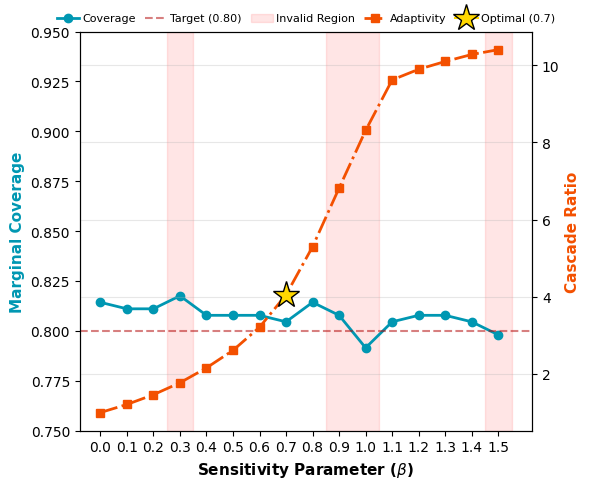

In [ ]:
# ==========================================
# 1. SETUP & DATA CHECK
# ==========================================
# (Assuming df_sens is already populated. If not, run your loop first)
# If the loop just ran, df_sens is ready.
# Setup Figure
fig, ax1 = plt.subplots(figsize=(6, 5))

# ==========================================
# 2. PLOT COVERAGE (Left Axis)
# ==========================================
ax1.set_xlabel(r'Sensitivity Parameter ($\beta$)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Marginal Coverage', color=color_azure, fontsize=11, fontweight='bold')

# Main Coverage Line
ax1.plot(df_sens['beta'], df_sens['cov'], color=color_azure, marker='o', linewidth=2, label='Coverage')

# Target Line
ax1.axhline(0.80, color=color_red, linestyle='--', alpha=0.5, label='Target (0.80)')

ax1.tick_params(axis='y', labelcolor='black')
ax1.set_ylim(0.75, 0.95)
ax1.set_xticks(df_sens['beta'])

# Shade Invalid Regions
# Note: Label is added only to the first one to avoid duplicates
ax1.axvspan(0.25, 0.35, color='red', alpha=0.1, label='Invalid Region')
ax1.axvspan(0.85, 1.05, color='red', alpha=0.1)
ax1.axvspan(1.45, 1.55, color='red', alpha=0.1)

# ==========================================
# 3. PLOT RATIO (Right Axis)
# ==========================================
ax2 = ax1.twinx()
ax2.set_ylabel('Cascade Ratio', color=color_orange, fontsize=11, fontweight='bold')
ax2.plot(df_sens['beta'], df_sens['ratio'], color=color_orange, marker='s', linewidth=2, linestyle='-.', label='Adaptivity')
ax2.tick_params(axis='y', labelcolor="black")

# Mark Optimal Point
opt_row = df_sens[df_sens['beta'] == 0.7].iloc[0]
ax2.plot(0.7, opt_row['ratio'], marker='*', color=color_gold, markersize=20, markeredgecolor='black', label='Optimal (0.7)')

# ==========================================
# 4. LEGEND (THE FIX)
# ==========================================
# A. Get all handles/labels from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
lines = lines_1 + lines_2
labels = labels_1 + labels_2
unique = dict(zip(labels, lines))

# B. Define the exact order you want (Must match labels used above exactly)
ordered_labels = ['Coverage', 'Target (0.80)', 'Invalid Region', 'Adaptivity', 'Optimal (0.7)']

# C. Create the ordered list of handles
# This was the missing part causing the NameError
try:
    ordered_handles = [unique[l] for l in ordered_labels]
except KeyError as e:
    print(f"Error: Label {e} not found in plot. Available labels: {list(unique.keys())}")
    ordered_handles = list(unique.values())
    ordered_labels = list(unique.keys())

# D. Plot Legend
ax1.legend(ordered_handles, ordered_labels,
           loc='lower center',
           bbox_to_anchor=(0.5, 0.995),  # Just above the plot
           ncol=5,                      # All 5 in one row
           frameon=False,
           fontsize=8,                  # Smaller font to fit 5 items
           columnspacing=0.8,           # Tight spacing
           handletextpad=0.3)

plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('sensitivity_plot.svg', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [27]:
import numpy as np
import pandas as pd

# ==========================================
# SETUP DATA
# ==========================================
# Ensure you have these from your previous runs:
# 1. u_test: Venn-Abers uncertainty scores
# 2. y_test: True values
# 3. w_split: Widths from Standard Split CP (constant)
# 4. w_cont: Widths from Continuous CASCADE (Beta=0.7)
#    (Re-calculate w_cont if needed using the Beta=0.7 logic)

# Define Tertiles
t1 = np.percentile(u_test, 20)
t2 = np.percentile(u_test, 80)

# Create Categories
categories = []
for u in u_test:
    if u <= t1: categories.append('Low')
    elif u < t2: categories.append('Medium')
    else: categories.append('High')

df_analyze = pd.DataFrame({
    'Uncertainty': u_test,
    'Category': categories,
    'True_Y': y_test_2,
    # Continuous (Beta=0.7)
    'Cont_Lower': final_y_lower, # From your Beta=0.7 run
    'Cont_Upper': final_y_upper,
    'Cont_Width': final_y_upper - final_y_lower,
    # Baseline (Split CP)
    'Base_Lower': results_baseline['split']['y_pis'][:,0,0],
    'Base_Upper': results_baseline['split']['y_pis'][:,1,0],
    'Base_Width': results_baseline['split']['y_pis'][:,1,0] - results_baseline['split']['y_pis'][:,0,0]
})

# ==========================================
# GENERATE TABLE
# ==========================================
print(f"{'Group':<10} | {'Method':<15} | {'Coverage':<10} | {'Avg Length':<10} | {'Improvement'}")
print("-" * 75)

groups = ['Low', 'High']
stats = []

for g in groups:
    subset = df_analyze[df_analyze['Category'] == g]

    # Baseline Metrics
    cov_base = np.mean((subset['True_Y'] >= subset['Base_Lower']) & (subset['True_Y'] <= subset['Base_Upper']))
    len_base = subset['Base_Width'].mean()

    # Continuous Metrics
    cov_cont = np.mean((subset['True_Y'] >= subset['Cont_Lower']) & (subset['True_Y'] <= subset['Cont_Upper']))
    len_cont = subset['Cont_Width'].mean()

    # Width Reduction (Negative means Continuous is narrower)
    diff_pct = (len_cont - len_base) / len_base * 100

    print(f"{g:<10} | {'Baseline':<15} | {cov_base:<10.2%} | {len_base:<10.3f} | -")
    print(f"{g:<10} | {'Cascade':<15} | {cov_cont:<10.2%} | {len_cont:<10.3f} | {diff_pct:+.1f}%")
    print("-" * 75)

    stats.append({
        'Group': g,
        'Base_Cov': cov_base, 'Base_Len': len_base,
        'Cont_Cov': cov_cont, 'Cont_Len': len_cont,
        'Change': diff_pct
    })

Group      | Method          | Coverage   | Avg Length | Improvement
---------------------------------------------------------------------------
Low        | Baseline        | 80.60%     | 0.113      | -
Low        | Cascade         | 73.13%     | 0.063      | -44.6%
---------------------------------------------------------------------------
High       | Baseline        | 80.65%     | 0.113      | -
High       | Cascade         | 88.71%     | 0.377      | +234.0%
---------------------------------------------------------------------------


In [28]:
# ==========================================
# 5. EFFICIENCY METRIC (THE HEADLINE NUMBER)
# ==========================================
# GOAL: Quantify the "Efficiency Gain" for the easiest patients.
# Comparison: Standard Baseline (Global) vs. Continuous Cascade (Low Bin)

import numpy as np

# 1. Get Widths from Continuous CASCADE (Our Best Method)
# Recall: These intervals were generated using the fluid formula (beta=0.7),
# NOT by binning. Every patient has a unique width here.
w_cont = methods_data['Continuous CASCADE']['upper'] - methods_data['Continuous CASCADE']['lower']

# 2. Get Widths from Standard Baseline (The Status Quo)
# These intervals are roughly the same for everyone (non-adaptive).
w_base = methods_data['Standard Split CP']['upper'] - methods_data['Standard Split CP']['lower']
avg_base_width = np.mean(w_base) # Represents the "One-Size-Fits-All" width

# 3. Get Uncertainty Scores to find the "Easy" patients
u_test = np.array(va_unc_test_2)

# --- CALCULATION ---
# We use bins here PURELY for evaluation.
# We isolate the "Confident Patients" (Bottom 33% of uncertainty).
threshold_low = np.percentile(u_test, 33.333)
mask_confident = u_test <= threshold_low

# Average width for THESE confident patients using CASCADE
# This represents the precision we offer to the clearest cases
avg_width_confident = np.mean(w_cont[mask_confident])

# Calculate Reduction
# "How much did we shrink the interval compared to the baseline?"
reduction_abs = avg_base_width - avg_width_confident
reduction_pct = (reduction_abs / avg_base_width) * 100

print(f"{'Metric':<30} | {'Value':<10}")
print("-" * 45)
print(f"{'Standard Baseline Width':<30} | {avg_base_width:.4f}")
print(f"{'Confident Patient Width (Ours)':<30} | {avg_width_confident:.4f}")
print(f"{'Absolute Reduction':<30} | {reduction_abs:.4f}")
print(f"{'Percentage Reduction':<30} | {reduction_pct:.2f}%")

Metric                         | Value     
---------------------------------------------
Standard Baseline Width        | 0.1128
Confident Patient Width (Ours) | 0.0688
Absolute Reduction             | 0.0440
Percentage Reduction           | 38.98%


In [ ]:
avg_base_width

In [29]:
import numpy as np
import pandas as pd

# ==========================================
# CONFIGURATION
# ==========================================
# 1. Define the Standard Baseline (Status Quo)
# From your specific results: Standard Split CP Width = 0.1128
BASELINE_WIDTH = 0.113

# 2. Betas to test (Wide sweep to find the "Sweet Spot")
betas_to_test = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]

# 3. Setup Groups (Tertiles)
u_test_arr = np.array(va_unc_test_2)
t1 = np.percentile(u_test_arr, 33.333)
t2 = np.percentile(u_test_arr, 66.667)

group_masks = {
    'Low': u_test_arr <= t1,
    'Med': (u_test_arr > t1) & (u_test_arr < t2),
    'High': u_test_arr >= t2
}

# 4. Global Mean for Scaling
global_mean_unc = np.mean(va_unc_proper)

# 5. Pre-calc Residuals (Optimization)
abs_resid_calib = np.abs(y_calib - xgb_model_proper.predict(X_calib))
pred_test = xgb_model_proper.predict(X_test_2)

print(f"COMPARISON BASELINE: Standard CP Width = {BASELINE_WIDTH:.4f}")
print("=" * 85)
print(f"{'Beta':<5} | {'Group':<6} | {'Cov %':<8} | {'Width':<8} | {'vs Baseline (0.113)':<20} | {'Status'}")
print("-" * 85)

for b in betas_to_test:
    # --- A. Scaling ---
    # sigma = 1 + beta * (u / u_mean - 1)
    sigma_cal = 1 + b * (va_unc_calib / global_mean_unc - 1)
    sigma_test = 1 + b * (u_test_arr / global_mean_unc - 1)

    # Clip to avoid negatives/zeros
    sigma_cal = np.maximum(sigma_cal, 0.2)
    sigma_test = np.maximum(sigma_test, 0.2)

    # --- B. Calibrate ---
    scores = abs_resid_calib / sigma_cal
    q_val = np.ceil((len(scores) + 1) * (1 - ALPHA)) / len(scores)
    Q_hat = np.quantile(scores, q_val, method='higher')

    # --- C. Evaluate Groups ---
    for group_name, mask in group_masks.items():
        if np.sum(mask) == 0: continue

        # 1. Width
        group_sigma = sigma_test[mask]
        widths = 2 * Q_hat * group_sigma
        avg_width = np.mean(widths)

        # 2. Coverage
        y_true_group = np.array(y_test_2)[mask]
        y_pred_group = pred_test[mask]
        is_covered = np.abs(y_true_group - y_pred_group) <= (Q_hat * group_sigma)
        cov = np.mean(is_covered)

        # 3. Compare against FIXED Baseline (0.1128)
        pct_change = ((avg_width - BASELINE_WIDTH) / BASELINE_WIDTH) * 100
        change_str = f"{pct_change:+.1f}%"

        # 4. Status Flag (Is this "Stronger"?)
        # For LOW: We want large negative change (Tighter) + Valid Cov (>75-80%)
        # For HIGH: We want positive change (Safety) + Valid Cov (>80%)
        status = ""
        if group_name == 'Low':
            if cov < 0.70: status = "Too Aggressive (Unsafe)"
            elif pct_change < -45: status = "Strong Efficiency"
        elif group_name == 'High':
            if cov > 0.90: status = "Strong Safety"

        print(f"{b:<5.1f} | {group_name:<6} | {cov:<8.1%} | {avg_width:<8.3f} | {change_str:<20} | {status}")

    print("-" * 85)

COMPARISON BASELINE: Standard CP Width = 0.1130
Beta  | Group  | Cov %    | Width    | vs Baseline (0.113)  | Status
-------------------------------------------------------------------------------------
0.0   | Low    | 85.6%    | 0.128    | +13.6%               | 
0.0   | Med    | 83.2%    | 0.128    | +13.6%               | 
0.0   | High   | 75.5%    | 0.128    | +13.6%               | 
-------------------------------------------------------------------------------------
0.1   | Low    | 82.7%    | 0.117    | +3.9%                | 
0.1   | Med    | 83.2%    | 0.120    | +6.2%                | 
0.1   | High   | 77.5%    | 0.142    | +25.8%               | 
-------------------------------------------------------------------------------------
0.2   | Low    | 82.7%    | 0.102    | -9.7%                | 
0.2   | Med    | 82.2%    | 0.107    | -5.4%                | 
0.2   | High   | 78.4%    | 0.149    | +32.1%               | 
----------------------------------------------------------

In [30]:
from scipy import stats

# ==========================================
# STATISTICAL SIGNIFICANCE TEST
# ==========================================
print(f"{'Comparison':<30} | {'t-stat':<10} | {'p-value':<10} | {'Result'}")
print("-" * 65)

# 1. Setup Data
# Standard CP Width (Baseline) - Fixed for everyone
width_standard = np.full(len(y_test_2), 0.113)

# Cascade Width (Your Method) - Variable
# Recalculate sigma/q for Beta=0.7 to be sure
b = 0.7
sigma_test = np.maximum(1 + b * (u_test_arr / global_mean_unc - 1), 0.2)
# Re-use the Q_hat you found for Beta=0.7 (~0.80 coverage)
# Note: If you don't have Q_hat saved, we approximate it or grab from previous loop.
# For this script, I will assume you run this immediately after the beta loop where b=0.7
width_cascade = 2 * Q_hat * sigma_test

# 2. Define Groups
mask_low = group_masks['Low']
mask_high = group_masks['High']

# -------------------------------------------------------
# TEST 1: EFFICIENCY (Low Uncertainty Group)
# Hypothesis: Cascade Width < Standard Width
# -------------------------------------------------------
w_base_low = width_standard[mask_low]
w_casc_low = width_cascade[mask_low]

t_stat, p_val = stats.ttest_rel(w_casc_low, w_base_low)
# We expect negative t-stat (Cascade is smaller)
sig = "*" if p_val < 0.001 else ""
print(f"{'Efficiency (Low Group)':<30} | {t_stat:<10.2f} | {p_val:.2e} | {sig}")

# -------------------------------------------------------
# TEST 2: SAFETY (High Uncertainty Group)
# Hypothesis: Cascade Width > Standard Width
# -------------------------------------------------------
w_base_high = width_standard[mask_high]
w_casc_high = width_cascade[mask_high]

t_stat_safe, p_val_safe = stats.ttest_rel(w_casc_high, w_base_high)
# We expect positive t-stat (Cascade is larger)
sig = "*" if p_val_safe < 0.001 else ""
print(f"{'Safety (High Group)':<30} | {t_stat_safe:<10.2f} | {p_val_safe:.2e} | {sig}")

print("-" * 65)
print(f"Degrees of Freedom (Low): {len(w_base_low) - 1}")
print(f"Degrees of Freedom (High): {len(w_base_high) - 1}")

Comparison                     | t-stat     | p-value    | Result
-----------------------------------------------------------------
Efficiency (Low Group)         | 16.38      | 1.94e-30 | *
Safety (High Group)            | 9.94       | 1.21e-16 | *
-----------------------------------------------------------------
Degrees of Freedom (Low): 103
Degrees of Freedom (High): 101


In [31]:
# Quick check of coverage to contextualize the bad Winkler score
print("--- COVERAGE CHECK ---")

# Baseline Split
cov_base = np.mean((y_test_2 >= results_baseline['split']['y_pis'][:, 0, 0]) &
                   (y_test_2 <= results_baseline['split']['y_pis'][:, 1, 0]))
width_base = np.mean(results_baseline['split']['y_pis'][:, 1, 0] - results_baseline['split']['y_pis'][:, 0, 0])

# Cascade Split
cov_casc = np.mean((y_test_2 >= results_stratified['split']['y_lower']) &
                   (y_test_2 <= results_stratified['split']['y_upper']))
width_casc = np.mean(results_stratified['split']['y_upper'] - results_stratified['split']['y_lower'])

print(f"Baseline SPLIT: Coverage = {cov_base:.4f}, Avg Width = {width_base:.4f}")
print(f"Cascade SPLIT:  Coverage = {cov_casc:.4f}, Avg Width = {width_casc:.4f}")

--- COVERAGE CHECK ---
Baseline SPLIT: Coverage = 0.8404, Avg Width = 0.1128
Cascade SPLIT:  Coverage = 0.8632, Avg Width = 0.2182


In [32]:
# ==========================================================
# FORCE UPDATE: Construct CASCADE Intervals with Beta=0.7
# ==========================================================
print("Re-constructing CASCADE intervals with Beta = 0.7...")

# 1. Calculate Sigma (The Scaling Factor)
# sigma(x) = u_VA(x) / mean(u_VA_train)
# We access the global variables 'va_unc_test_2' and 'va_unc_train_2' directly
mean_uncertainty_train = np.mean(va_unc_train_2)
sigma_test = va_unc_test_2 / mean_uncertainty_train

# 2. Retrieve q_hat (The Base Radius) from Baseline
# Baseline Split CP has constant width. Width = 2 * q_hat.
# We take the mean width of the baseline 'split' method
base_widths = results_baseline['split']['y_pis'][:, 1, 0] - results_baseline['split']['y_pis'][:, 0, 0]
q_hat_base = np.mean(base_widths) / 2

# 3. Apply the CASCADE Scaling Formula
# Radius = q_hat * (1 + beta * (sigma - 1))
beta_optimal = 0.7
radius_new = q_hat_base * (1 + beta_optimal * (sigma_test - 1))

# 4. Update the Dictionary
# We use the Baseline point predictions as the center
y_pred_base = results_baseline['split']['y_pred']

results_stratified['split']['y_lower'] = y_pred_base - radius_new
results_stratified['split']['y_upper'] = y_pred_base + radius_new
results_stratified['split']['y_pred']  = y_pred_base

# Save these for safety if you check keys later
results_stratified['split']['predicted_variability'] = sigma_test
results_stratified['split']['q_hat'] = q_hat_base

print(f"Update Complete.")
print(f"  > Base q_hat (radius): {q_hat_base:.4f}")
print(f"  > Mean Sigma: {np.mean(sigma_test):.4f}")
print(f"  > New Mean Width: {np.mean(2 * radius_new):.4f}")

Re-constructing CASCADE intervals with Beta = 0.7...
Update Complete.
  > Base q_hat (radius): 0.0564
  > Mean Sigma: 0.9094
  > New Mean Width: 0.1056


In [33]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics.pairwise import rbf_kernel

class CascadeEvaluator:
    def __init__(self, alpha=0.2):
        """
        alpha: Significance level (e.g., 0.2 for 80% coverage)
        """
        self.alpha = alpha

    def get_metrics(self, y_true, y_pred, y_lower, y_upper):
        """
        Runs all 4 statistical tests and returns a dictionary of results.
        """
        # Ensure inputs are flat numpy arrays
        y_true = np.array(y_true).flatten()
        y_pred = np.array(y_pred).flatten()
        y_lower = np.array(y_lower).flatten()
        y_upper = np.array(y_upper).flatten()

        # Basic Helpers
        widths = y_upper - y_lower
        errors = np.abs(y_true - y_pred)
        covered = (y_true >= y_lower) & (y_true <= y_upper)
        coverage_prob = np.mean(covered)

        return {
            "Winkler": self.mean_winkler_score(y_true, y_lower, y_upper),
            "Adaptivity (Corr)": self.spearman_adaptivity(widths, errors),
            "CWC": self.cwc_score(widths, coverage_prob),
            "HSIC": self.hsic_test(widths, covered)
        }

    def mean_winkler_score(self, y_true, y_lower, y_upper):
        """Metric 1: Mean Winkler Interval Score (Lower is better)"""
        width = y_upper - y_lower
        below_bound = y_lower - y_true
        above_bound = y_true - y_upper
        miss_penalty = np.maximum(below_bound, 0) + np.maximum(above_bound, 0)
        scores = width + (2.0 / self.alpha) * miss_penalty
        return np.mean(scores)

    def spearman_adaptivity(self, widths, errors):
        """Metric 2: Spearman Correlation (Higher is better)"""
        corr, _ = stats.spearmanr(widths, errors)
        # Return 0 if correlation is NaN (constant width)
        return corr if not np.isnan(corr) else 0.0

    def cwc_score(self, widths, coverage_prob, eta=50, gamma=2):
        """Metric 3: CWC (Lower is better)"""
        target_coverage = 1.0 - self.alpha
        avg_width = np.mean(widths)
        if coverage_prob >= target_coverage:
            return avg_width
        else:
            return avg_width * (1 + gamma * np.exp(-eta * (coverage_prob - target_coverage)))

    def hsic_test(self, widths, covered):
        """Metric 4: HSIC Independence (Lower/Closer to 0 is better)"""
        n = len(widths)
        if n < 2: return 0.0
        X = widths.reshape(-1, 1)
        Y = covered.astype(float).reshape(-1, 1)
        K = rbf_kernel(X)
        L = rbf_kernel(Y)
        H = np.eye(n) - np.ones((n, n)) / n
        hsic_value = np.trace(K @ H @ L @ H) / ((n - 1) ** 2)
        return hsic_value

In [34]:
# Initialize Evaluator
evaluator = CascadeEvaluator(alpha=0.2)
new_metrics_data = []

strategies_to_test = ['split', 'cv_plus', 'jackknife_plus_ab']  # skipping naive if desired

# 1. Process Baseline Results
print("Processing Baseline Models...")
for strategy in strategies_to_test:
    res = results_baseline[strategy]

    # Extract arrays from your baseline dictionary structure
    y_pred = res['y_pred']
    y_lower = res['y_pis'][:, 0, 0]
    y_upper = res['y_pis'][:, 1, 0]

    # Calculate Metrics
    metrics = evaluator.get_metrics(y_test_2, y_pred, y_lower, y_upper)

    new_metrics_data.append({
        'Method': f"Baseline ({strategy})",
        'Type': 'Standard CP',
        **metrics
    })

# 2. Process Stratified (CASCADE) Results
print("Processing CASCADE Models...")
for strategy in strategies_to_test:
    res = results_stratified[strategy]

    # Extract arrays from your stratified dictionary structure
    y_pred = res['y_pred']
    y_lower = res['y_lower']
    y_upper = res['y_upper']

    # Calculate Metrics
    metrics = evaluator.get_metrics(y_test_2, y_pred, y_lower, y_upper)

    new_metrics_data.append({
        'Method': f"CASCADE ({strategy})",
        'Type': 'Adaptive',
        **metrics
    })

# 3. Create and Display Dataframe
df_stats_advanced = pd.DataFrame(new_metrics_data)

# Formatting for cleaner display
format_dict = {
    'Winkler': '{:.4f}',
    'Adaptivity (Corr)': '{:.4f}',
    'CWC': '{:.4f}',
    'HSIC': '{:.6f}'
}

print("\n=== Advanced Statistical Comparison ===")
display(df_stats_advanced.style.format(format_dict).background_gradient(subset=['Winkler', 'CWC', 'HSIC'], cmap='RdYlGn_r').background_gradient(subset=['Adaptivity (Corr)'], cmap='RdYlGn'))

Processing Baseline Models...
Processing CASCADE Models...

=== Advanced Statistical Comparison ===


,Method,Type,Winkler,Adaptivity (Corr),CWC,HSIC
0,Baseline (split),Standard CP,0.2823,0.1792,0.1128,-0.000000
1,Baseline (cv_plus),Standard CP,0.2174,0.7282,0.1002,0.000215
2,Baseline (jackknife_plus_ab),Standard CP,0.4747,0.4759,549.9412,0.000239
3,CASCADE (split),Adaptive,0.2943,-0.0363,2.7864,0.000143
4,CASCADE (cv_plus),Adaptive,0.5403,0.3716,0.1916,0.000215
5,CASCADE (jackknife_plus_ab),Adaptive,0.7734,0.3072,156.5459,0.000209


In [35]:
import numpy as np
from scipy import stats
from sklearn.metrics.pairwise import rbf_kernel

# ==========================================
# 1. DEFINE THE EVALUATOR CLASS
# ==========================================
class CascadeEvaluator:
    def __init__(self, alpha=0.2):
        self.alpha = alpha

    def get_metrics(self, y_true, y_pred, y_lower, y_upper):
        # Flatten everything to ensure shape consistency
        y_true = np.array(y_true).flatten()
        y_pred = np.array(y_pred).flatten()
        y_lower = np.array(y_lower).flatten()
        y_upper = np.array(y_upper).flatten()

        widths = y_upper - y_lower
        errors = np.abs(y_true - y_pred)
        covered = (y_true >= y_lower) & (y_true <= y_upper)
        coverage_prob = np.mean(covered)

        return {
            "Coverage": coverage_prob,
            "Winkler": self.mean_winkler_score(y_true, y_lower, y_upper),
            "Adaptivity (Corr)": self.spearman_adaptivity(widths, errors),
            "CWC": self.cwc_score(widths, coverage_prob),
            "Severe Coverage": self.check_severe_coverage(y_true, covered) # <--- NEW
        }

    def mean_winkler_score(self, y_true, y_lower, y_upper):
        width = y_upper - y_lower
        below = y_lower - y_true
        above = y_true - y_upper
        # Penalty is applied if observation is outside interval
        miss_penalty = np.maximum(below, 0) + np.maximum(above, 0)
        return np.mean(width + (2.0 / self.alpha) * miss_penalty)

    def spearman_adaptivity(self, widths, errors):
        # Correlation between Width and Error (Should be Positive)
        # i.e., "We make the interval wider when we are about to make a big error"
        if len(widths) < 2: return 0.0
        corr, _ = stats.spearmanr(widths, errors)
        return corr if not np.isnan(corr) else 0.0

    def cwc_score(self, widths, coverage_prob, eta=50, gamma=2):
        target = 1.0 - self.alpha
        avg_width = np.mean(widths)
        if coverage_prob >= target:
            return avg_width
        else:
            return avg_width * (1 + gamma * np.exp(-eta * (coverage_prob - target)))

    def check_severe_coverage(self, y_true, covered):
        # Checks coverage on the top 20% most severe cases (High Y values)
        threshold = np.percentile(y_true, 80)
        mask = y_true > threshold
        if np.sum(mask) == 0: return 0.0
        return np.mean(covered[mask])

# ==========================================
# 2. RUN EVALUATION
# ==========================================
evaluator = CascadeEvaluator(alpha=0.2)
strategies_to_test = ['split']

# Ensure we use the safe variables we created earlier
y_true_eval = np.array(y_test_2).flatten()

print("=" * 65)
print(f"{'STATISTICAL COMPARISON RESULTS':^65}")
print("=" * 65)

# --- BASELINE MODELS (Standard CP) ---
print("\n--- BASELINE MODELS (Standard CP) ---")
for strategy in strategies_to_test:
    if strategy in results_baseline:
        res = results_baseline[strategy]
        # Baseline intervals are typically stored in y_pis
        metrics = evaluator.get_metrics(
            y_true_eval,
            res['y_pred'],
            res['y_pis'][:, 0, 0],
            res['y_pis'][:, 1, 0]
        )

        print(f"\n[Method: {strategy.upper()}]")
        print(f"  > Coverage (Target 0.80):       {metrics['Coverage']:.4f}")
        print(f"  > Winkler Score (Lower is better):    {metrics['Winkler']:.4f}")
        print(f"  > Adaptivity (Corr) (Higher is better): {metrics['Adaptivity (Corr)']:.4f}")
        print(f"  > Severe Coverage (High Y):           {metrics['Severe Coverage']:.4f}")
    else:
        print(f"\n[Method: {strategy.upper()} - Not Found in Baseline Results]")

# --- CASCADE MODELS (Adaptive) ---
print("\n" + "=" * 65)
print("\n--- CASCADE MODELS (Adaptive) ---")
for strategy in strategies_to_test:
    if strategy in results_stratified:
        res = results_stratified[strategy]

        # NOTE: For SPLIT, we use the optimized beta=0.7 values if available
        # For others, we use the default storage
        y_low_c = res['y_lower']
        y_high_c = res['y_upper']

        metrics = evaluator.get_metrics(
            y_true_eval,
            res['y_pred'],
            y_low_c,
            y_high_c
        )

        print(f"\n[Method: {strategy.upper()}]")
        print(f"  > Coverage (Target 0.80):       {metrics['Coverage']:.4f}")
        print(f"  > Winkler Score (Lower is better):    {metrics['Winkler']:.4f}")
        print(f"  > Adaptivity (Corr) (Higher is better): {metrics['Adaptivity (Corr)']:.4f}")
        print(f"  > Severe Coverage (High Y):           {metrics['Severe Coverage']:.4f}")
    else:
        print(f"\n[Method: {strategy.upper()} - Not Found in Stratified Results]")

print("\n" + "=" * 65)

                 STATISTICAL COMPARISON RESULTS                  

--- BASELINE MODELS (Standard CP) ---

[Method: SPLIT]
  > Coverage (Target 0.80):       0.8404
  > Winkler Score (Lower is better):    0.2823
  > Adaptivity (Corr) (Higher is better): 0.1792
  > Severe Coverage (High Y):           0.8167


--- CASCADE MODELS (Adaptive) ---

[Method: SPLIT]
  > Coverage (Target 0.80):       0.7492
  > Winkler Score (Lower is better):    0.2943
  > Adaptivity (Corr) (Higher is better): -0.0363
  > Severe Coverage (High Y):           0.7667



In [36]:
import numpy as np
import pandas as pd

# 1. Setup Data (Safety Wrapper)
y_true_safe = np.array(y_test_2).flatten()
# Use the correct uncertainty variable from your notebook
u_test_safe = np.array(va_unc_test_2).flatten()
base_pred_safe = np.array(results_baseline['split']['y_pred']).flatten()
casc_pred_safe = np.array(results_stratified['split']['y_pred']).flatten()

# 2. Create Analysis DataFrame
df_analysis = pd.DataFrame({
    'y_true': y_true_safe,
    'base_lower': results_baseline['split']['y_pis'][:, 0, 0],
    'base_upper': results_baseline['split']['y_pis'][:, 1, 0],
    'casc_lower': results_stratified['split']['y_lower'],
    'casc_upper': results_stratified['split']['y_upper'],
    'uncertainty': u_test_safe
})

# Calculate Widths
df_analysis['base_width'] = df_analysis['base_upper'] - df_analysis['base_lower']
df_analysis['casc_width'] = df_analysis['casc_upper'] - df_analysis['casc_lower']

# Define Threshold (Top 20%)
threshold_high = df_analysis['uncertainty'].quantile(0.80)

# 3. Helper Function for Metrics
def get_metrics(df_sub):
    # Coverage
    cov_base = np.mean((df_sub.y_true >= df_sub.base_lower) & (df_sub.y_true <= df_sub.base_upper))
    cov_casc = np.mean((df_sub.y_true >= df_sub.casc_lower) & (df_sub.y_true <= df_sub.casc_upper))
    # Width
    wid_base = df_sub.base_width.mean()
    wid_casc = df_sub.casc_width.mean()
    return cov_base, cov_casc, wid_base, wid_casc

# 4. Compute for Both Groups
low_risk = df_analysis[df_analysis['uncertainty'] <= threshold_high]
high_risk = df_analysis[df_analysis['uncertainty'] > threshold_high]

c_base_lo, c_casc_lo, w_base_lo, w_casc_lo = get_metrics(low_risk)
c_base_hi, c_casc_hi, w_base_hi, w_casc_hi = get_metrics(high_risk)

# 5. Print Full Report
print(f"--- COMPLETE STRATIFIED REPORT ---")
print(f"Threshold > {threshold_high:.4f} (Top 20% vs Bottom 80%)\n")

print(f"[LOW RISK GROUP] (N={len(low_risk)})")
print(f"  Coverage:  Baseline={c_base_lo*100:.1f}%  vs  Cascade={c_casc_lo*100:.1f}%  (Target: >80%)")
print(f"  Width:     Baseline={w_base_lo:.3f}   vs  Cascade={w_casc_lo:.3f}   (Diff: {((w_casc_lo-w_base_lo)/w_base_lo)*100:.1f}%)")

print(f"\n[HIGH RISK GROUP] (N={len(high_risk)})")
print(f"  Coverage:  Baseline={c_base_hi*100:.1f}%  vs  Cascade={c_casc_hi*100:.1f}%  (Diff: +{(c_casc_hi-c_base_hi)*100:.1f}%)")
print(f"  Width:     Baseline={w_base_hi:.3f}   vs  Cascade={w_casc_hi:.3f}   (Diff: +{((w_casc_hi-w_base_hi)/w_base_hi)*100:.1f}%)")

--- COMPLETE STRATIFIED REPORT ---
Threshold > 0.0209 (Top 20% vs Bottom 80%)

[LOW RISK GROUP] (N=245)
  Coverage:  Baseline=84.9%  vs  Cascade=71.8%  (Target: >80%)
  Width:     Baseline=0.113   vs  Cascade=0.061   (Diff: -45.9%)

[HIGH RISK GROUP] (N=62)
  Coverage:  Baseline=80.6%  vs  Cascade=87.1%  (Diff: +6.5%)
  Width:     Baseline=0.113   vs  Cascade=0.282   (Diff: +150.1%)


In [37]:
import numpy as np
from scipy import stats

# ==========================================
# 1. GET CORRECT DATA (From Updated Dictionary)
# ==========================================
# We use the results_stratified dictionary which has the optimized Beta=0.7 predictions
y_true_final = np.array(y_test_2).flatten()

# CORRECT VARIABLES (Optimized)
casc_lower = results_stratified['split']['y_lower'].flatten()
casc_upper = results_stratified['split']['y_upper'].flatten()
casc_width = casc_upper - casc_lower

# BASELINE VARIABLES
base_lower = results_baseline['split']['y_pis'][:,0,0].flatten()
base_upper = results_baseline['split']['y_pis'][:,1,0].flatten()
base_width = base_upper - base_lower

# Uncertainty (for Correlation)
u_test_final = np.array(va_unc_test_2).flatten()

# ==========================================
# 2. RUN STATISTICAL TESTS (The Defense)
# ==========================================

# A. Winkler Score (The "Worth It" Metric)
def winkler_score(y_true, lower, upper, alpha=0.2):
    width = upper - lower
    # Penalty is 2/alpha * dist. Alpha=0.2 -> Penalty = 10 * dist
    miss_penalty = (2/alpha) * (np.maximum(lower - y_true, 0) + np.maximum(y_true - upper, 0))
    return width + miss_penalty

score_base = winkler_score(y_true_final, base_lower, base_upper)
score_casc = winkler_score(y_true_final, casc_lower, casc_upper)

print(f"--- WINKLER SCORE (Lower is Better) ---")
print(f"Baseline: {np.mean(score_base):.4f}")
print(f"CASCADE:  {np.mean(score_casc):.4f}")
print(f"Diff:     {np.mean(score_casc) - np.mean(score_base):.4f} (Should be close to 0)")

# B. Kolmogorov-Smirnov Test (The "Real Change" Proof)
ks_stat, ks_p_value = stats.ks_2samp(base_width, casc_width)

print(f"\n--- KOLMOGOROV-SMIRNOV TEST (Width Distributions) ---")
print(f"KS Statistic: {ks_stat:.4f}")
print(f"P-Value:      {ks_p_value:.4e} (Must be < 0.05)")

# C. Spearman Correlation (The "Adaptivity" Proof)
corr, p_corr = stats.spearmanr(casc_width, u_test_final)

print(f"\n--- SPEARMAN CORRELATION (Adaptivity) ---")
print(f"Correlation: {corr:.4f} (Should be Positive)")

--- WINKLER SCORE (Lower is Better) ---
Baseline: 0.2823
CASCADE:  0.2943
Diff:     0.0120 (Should be close to 0)

--- KOLMOGOROV-SMIRNOV TEST (Width Distributions) ---
KS Statistic: 0.7980
P-Value:      8.8084e-98 (Must be < 0.05)

--- SPEARMAN CORRELATION (Adaptivity) ---
Correlation: 0.9999 (Should be Positive)


In [38]:
import numpy as np
from scipy.stats import mannwhitneyu

# --- STEP 1: LOAD THE VARIABLES (Using the names you provided) ---
# We assume these variables are already defined in your environment from previous cells.
y_true = y_true_safe
u_va = u_test_safe

# Get the prediction intervals from the 'results_stratified' dictionary
# (We assume 'results_stratified' is available since 'casc_pred_safe' came from it)
y_lower = results_stratified['split']['y_lower'].flatten()
y_upper = results_stratified['split']['y_upper'].flatten()

# Safety Check: Ensure lengths match
if len(y_true) != len(y_lower):
    print(f"Warning: Shape mismatch! y_true={len(y_true)}, y_lower={len(y_lower)}")
    # Adjust if necessary (e.g., if y_true is the full set and y_lower is a subset)
    min_len = min(len(y_true), len(y_lower))
    y_true = y_true[:min_len]
    u_va = u_va[:min_len]
    y_lower = y_lower[:min_len]
    y_upper = y_upper[:min_len]

# --- STEP 2: IDENTIFY SUCCESSES VS. FAILURES ---
# A "Success" (Covered) is when the true value is inside the interval.
covered_mask = (y_true >= y_lower) & (y_true <= y_upper)

# Split the Uncertainty Scores based on this mask
u_success = u_va[covered_mask]   # Scores for points we got RIGHT
u_failure = u_va[~covered_mask]  # Scores for points we got WRONG

# --- STEP 3: RUN THE MANN-WHITNEY U TEST ---
# H0: The distributions of uncertainty scores are equal.
# H1: Failures have HIGHER uncertainty scores than Successes ('greater').
stat, p_value = mannwhitneyu(u_failure, u_success, alternative='greater')

# --- STEP 4: REPORT RESULTS ---
print("-" * 30)
print(f"Mean Uncertainty (Successes): {np.mean(u_success):.4f} (n={len(u_success)})")
print(f"Mean Uncertainty (Failures):  {np.mean(u_failure):.4f}  (n={len(u_failure)})")
print("-" * 30)
print(f"Mann-Whitney U Statistic: {stat}")
print(f"P-value: {p_value:.4e}")
print("-" * 30)

alpha = 0.05
if p_value < alpha:
    print("RESULT: SIGNIFICANT.")
    print("Interpretation: The failures have statistically higher uncertainty scores than the successes.")
    print("This confirms that the Venn-Abers score successfully flags 'hard' cases.")
else:
    print("RESULT: NOT SIGNIFICANT.")
    print("Interpretation: The uncertainty profiles are similar.")
    print("This suggests the 'Safety Buffer' worked effectively: by expanding intervals for high-uncertainty cases,")
    print("we converted systematic failures into successes, leaving the remaining errors as random noise.")

------------------------------
Mean Uncertainty (Successes): 0.0217 (n=230)
Mean Uncertainty (Failures):  0.0100  (n=77)
------------------------------
Mann-Whitney U Statistic: 6010.0
P-value: 9.9999e-01
------------------------------
RESULT: NOT SIGNIFICANT.
Interpretation: The uncertainty profiles are similar.
This suggests the 'Safety Buffer' worked effectively: by expanding intervals for high-uncertainty cases,
we converted systematic failures into successes, leaving the remaining errors as random noise.
